# Proyek Akhir: Menyelesaikan Permasalahan Perusahaan Edutech

- Nama: Adnin Danil Azkia
- Email: adnindanil03@gmail.com
- Id Dicoding: adnindanil

## Persiapan

### Menyiapkan library yang dibutuhkan

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

### Menyiapkan data yang akan diguankan

## Data Understanding

In [2]:
df = pd.read_csv("data/data.csv", delimiter=';')
pd.set_option('display.max_columns', None)
df.head()

,Marital_status,Application_mode,Application_order,Course,Daytime_evening_attendance,Previous_qualification,Previous_qualification_grade,Nacionality,Mothers_qualification,Fathers_qualification,Mothers_occupation,Fathers_occupation,Admission_grade,Displaced,Educational_special_needs,Debtor,Tuition_fees_up_to_date,Gender,Scholarship_holder,Age_at_enrollment,International,Curricular_units_1st_sem_credited,Curricular_units_1st_sem_enrolled,Curricular_units_1st_sem_evaluations,Curricular_units_1st_sem_approved,Curricular_units_1st_sem_grade,Curricular_units_1st_sem_without_evaluations,Curricular_units_2nd_sem_credited,Curricular_units_2nd_sem_enrolled,Curricular_units_2nd_sem_evaluations,Curricular_units_2nd_sem_approved,Curricular_units_2nd_sem_grade,Curricular_units_2nd_sem_without_evaluations,Unemployment_rate,Inflation_rate,GDP,Status
0,1,17,5,171,1,1,122.0,1,19,12,5,9,127.3,1,0,0,1,1,0,20,0,0,0,0,0,0.000000,0,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,3,3,142.5,1,0,0,0,1,0,19,0,0,6,6,6,14.000000,0,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,9,9,124.8,1,0,0,0,1,0,19,0,0,6,0,0,0.000000,0,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,5,3,119.6,1,0,0,1,0,0,20,0,0,6,8,6,13.428571,0,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,9,9,141.5,0,0,0,1,0,0,45,0,0,6,9,5,12.333333,0,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


In [3]:
df.isna().sum()

Marital_status                                  0
Application_mode                                0
Application_order                               0
Course                                          0
Daytime_evening_attendance                      0
Previous_qualification                          0
Previous_qualification_grade                    0
Nacionality                                     0
Mothers_qualification                           0
Fathers_qualification                           0
Mothers_occupation                              0
Fathers_occupation                              0
Admission_grade                                 0
Displaced                                       0
Educational_special_needs                       0
Debtor                                          0
Tuition_fees_up_to_date                         0
Gender                                          0
Scholarship_holder                              0
Age_at_enrollment                               0


In [4]:
df.duplicated().sum()

np.int64(0)

In [5]:
df['Status'].value_counts()

Status
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64

In [6]:
df_copy = df.copy()
marital_status_map = {
    1: 'single',
    2: 'married',
    3: 'widower',
    4: 'divorced',
    5: 'facto union',
    6: 'legally separated'
}

df_copy['martial_status_label'] = df_copy['Marital_status'].map(marital_status_map)
print(df_copy[['Marital_status', 'martial_status_label']].head())

   Marital_status martial_status_label
0               1               single
1               1               single
2               1               single
3               1               single
4               2              married


In [7]:
gender_map = {
    1: 'male',
    0: 'female'
}

df_copy['gender_label'] = df_copy['Gender'].map(gender_map)
print(df_copy[['Gender', 'gender_label']].head())

   Gender gender_label
0       1         male
1       1         male
2       1         male
3       0       female
4       0       female


In [8]:
nationality_map = {
    1: 'Portuguese', 2: 'German', 6: 'Spanish', 11: 'Italian', 13: 'Dutch', 
    14: 'English', 17: 'Lithuanian', 21: 'Angolan', 22: 'Cape Verdean', 
    24: 'Guinean', 25: 'Mozambican', 26: 'Santomean', 32: 'Turkish', 
    41: 'Brazilian', 62: 'Romanian', 100: 'Moldova (Republic of)', 
    101: 'Mexican', 103: 'Ukrainian', 105: 'Russian', 108: 'Cuban', 
    109: 'Colombian'
}

df_copy['nacionality_label'] = df_copy['Nacionality'].map(nationality_map)
print(df_copy[['Nacionality', 'nacionality_label']].head())

   Nacionality nacionality_label
0            1        Portuguese
1            1        Portuguese
2            1        Portuguese
3            1        Portuguese
4            1        Portuguese


In [9]:
df_copy['scholarship_label'] = df_copy['Scholarship_holder'].map({
    1: 'Yes',
    0: 'No'
})

df_copy['debtor_label'] = df_copy['Debtor'].map({
    1: 'Yes',
    0: 'No'
})

In [10]:
df_copy.columns

Index(['Marital_status', 'Application_mode', 'Application_order', 'Course',
       'Daytime_evening_attendance', 'Previous_qualification',
       'Previous_qualification_grade', 'Nacionality', 'Mothers_qualification',
       'Fathers_qualification', 'Mothers_occupation', 'Fathers_occupation',
       'Admission_grade', 'Displaced', 'Educational_special_needs', 'Debtor',
       'Tuition_fees_up_to_date', 'Gender', 'Scholarship_holder',
       'Age_at_enrollment', 'International',
       'Curricular_units_1st_sem_credited',
       'Curricular_units_1st_sem_enrolled',
       'Curricular_units_1st_sem_evaluations',
       'Curricular_units_1st_sem_approved', 'Curricular_units_1st_sem_grade',
       'Curricular_units_1st_sem_without_evaluations',
       'Curricular_units_2nd_sem_credited',
       'Curricular_units_2nd_sem_enrolled',
       'Curricular_units_2nd_sem_evaluations',
       'Curricular_units_2nd_sem_approved', 'Curricular_units_2nd_sem_grade',
       'Curricular_units_2nd_sem_wit

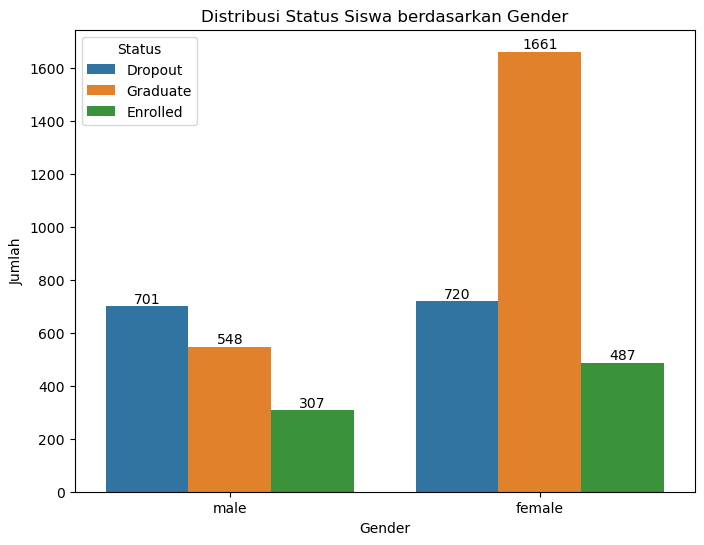

In [11]:
plt.figure(figsize=(8, 6))
ax = sns.countplot(data=df_copy, x='gender_label', hue='Status')

for container in ax.containers:
    ax.bar_label(container)
plt.title('Distribusi Status Siswa berdasarkan Gender')
plt.xlabel('Gender')
plt.ylabel('Jumlah')
plt.legend(title='Status')
plt.show()

Siswa laki-laki memiliki tingkat Dropout yang jauh lebih besar, dimana lebih dari 50% dari mereka tidak menyelesaikan pendidikannya (Dropout). Hal ini berbanding terbalik dengan siswa perempuan yang dimana memiliki tingkat Dropout yang jauh lebih rendah.

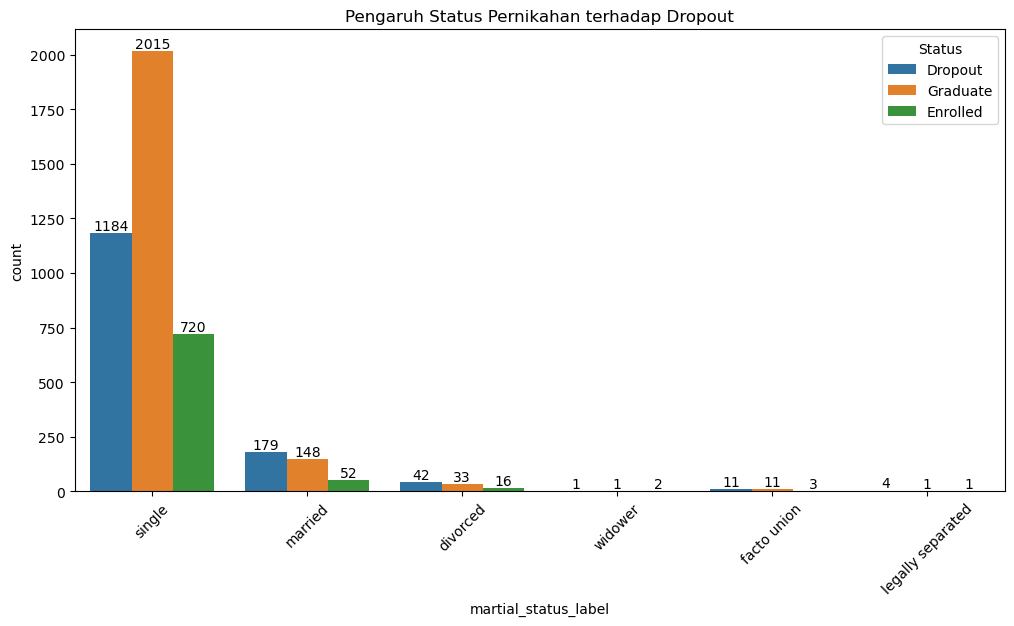

In [12]:
plt.figure(figsize=(12, 6))
ax = sns.countplot(data=df_copy, x='martial_status_label', hue='Status')

for container in ax.containers:
    ax.bar_label(container)

plt.title('Pengaruh Status Pernikahan terhadap Dropout')
plt.xticks(rotation=45)
plt.show()

Status pernikahan menunjukkan korelasi yang signifikan terhadap kelulusan siswa. Siswa yang masih single memiliki tingkat kelulusan yang lebih tinggi dibandingkan dengan tingkat dropoutnya. Sebaliknya, resiko dropout menigkat secara drastis pada siswa yang sudah menikah. Pada kelompok ini tingkat dropout nya mencapai lebih dari 50%

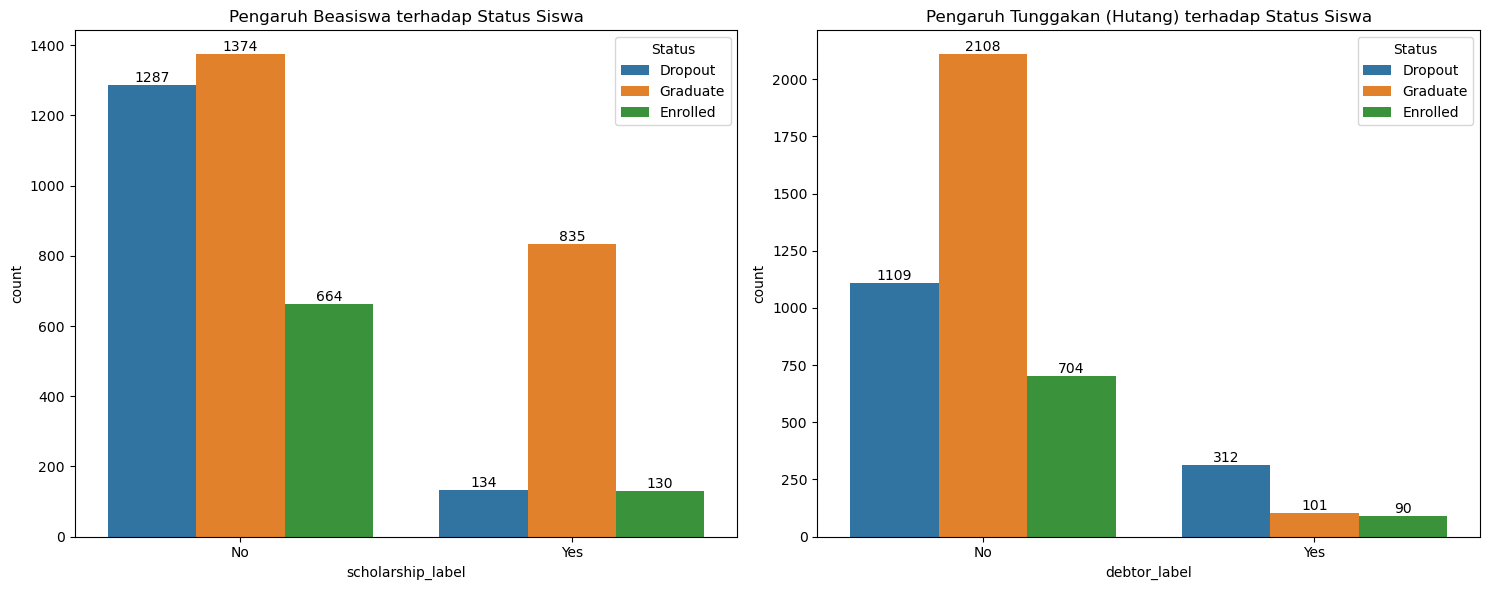

In [13]:
fig, ax = plt.subplots(1, 2, figsize=(15, 6))

sns.countplot(data=df_copy, x='scholarship_label', hue='Status', ax=ax[0])
ax[0].set_title('Pengaruh Beasiswa terhadap Status Siswa')
for container in ax[0].containers:
    ax[0].bar_label(container)
    
sns.countplot(data=df_copy, x='debtor_label', hue='Status', ax=ax[1])
ax[1].set_title('Pengaruh Tunggakan (Hutang) terhadap Status Siswa')
for container in ax[1].containers:
    ax[1].bar_label(container)
    
plt.tight_layout()
plt.show()

Kondisi ekonomi memiliki korelasi yang sangat kuat dengan stabilitas akademik siswa di Jaya Jaya Institut. Dukungan finansial terbukti menjadi faktor pelindung, di mana banyak dari siswa yang menerima scholarship (beasiswa) memiliki peluang lulus lebih tinggi. Sebaliknya, hambatan finansial yang tercermin dari adanya tunggakan (hutang) meningkatkan faktor dropout dari siswa. Hal ini mengindikasikan bahwa finansial merupakan salah satu strategi kunci untuk menekan tingginya dropout.

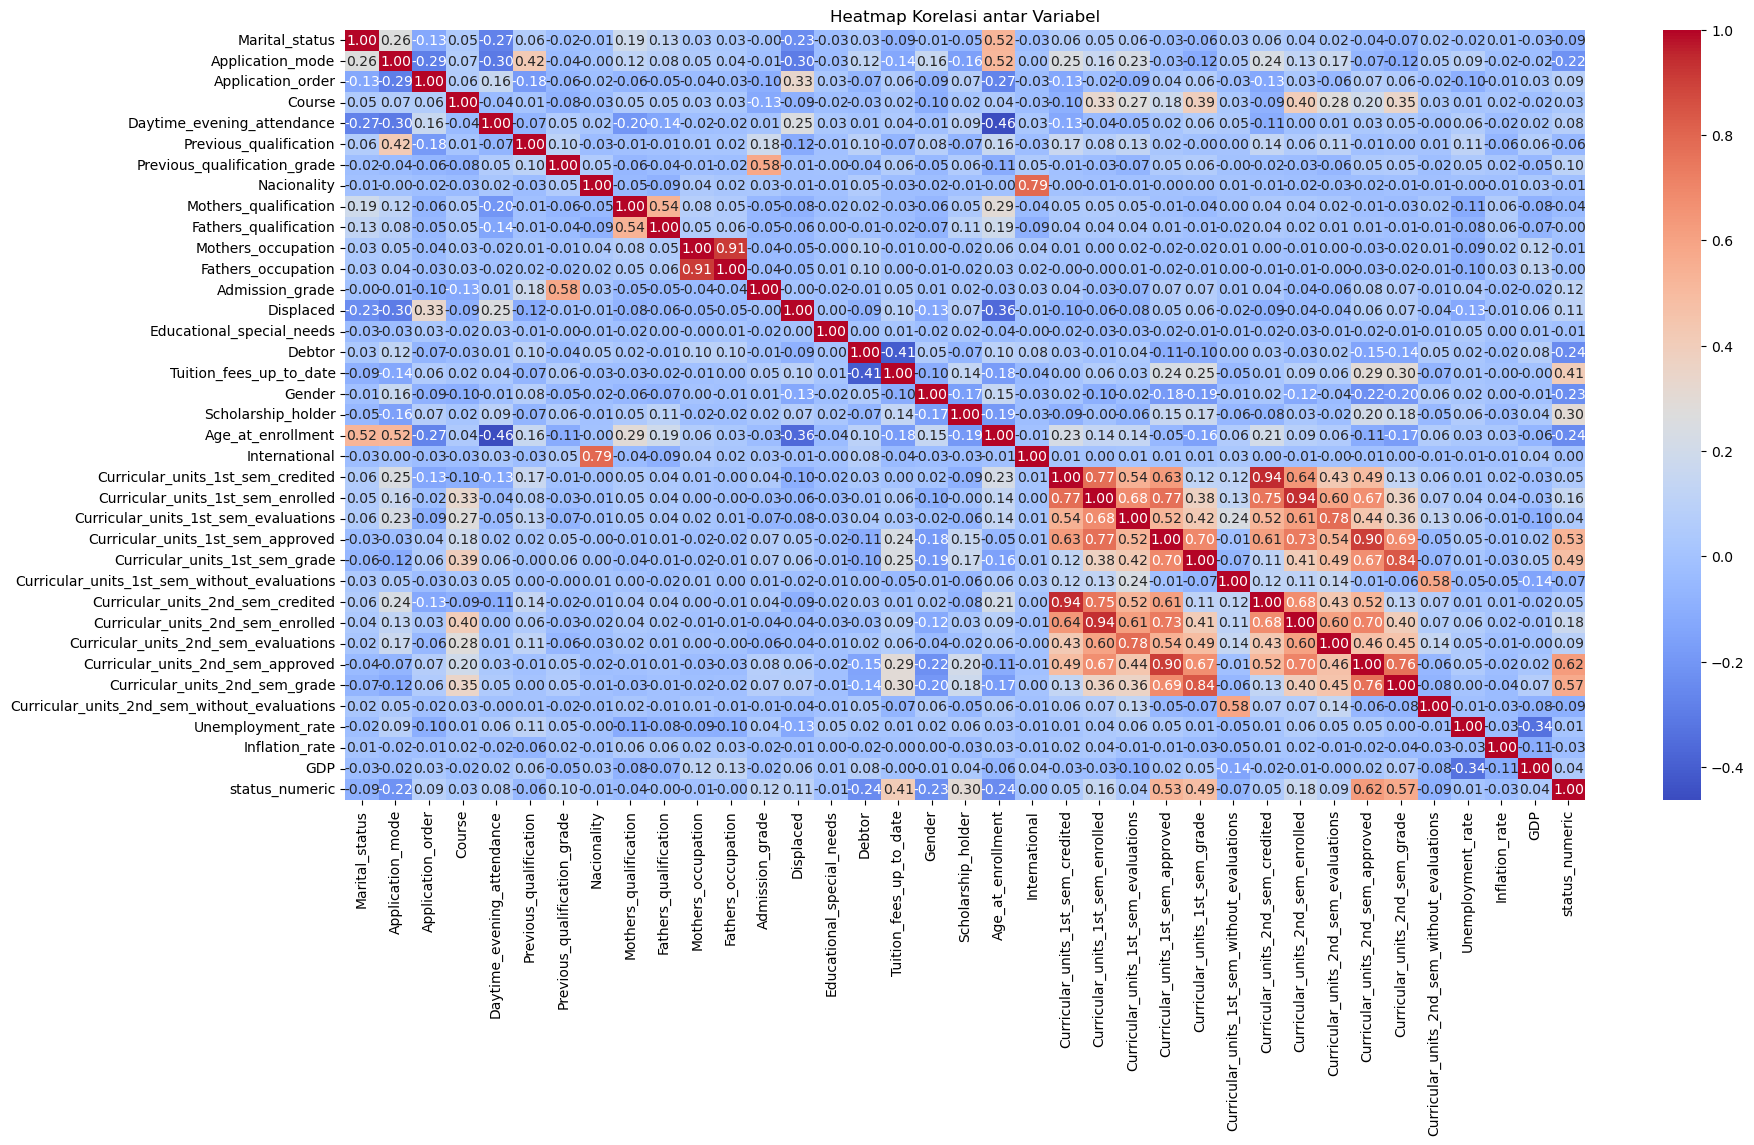

In [14]:
df_corr = df_copy.copy()

df_corr['status_numeric'] = df_corr['Status'].map({
    'Graduate': 2,
    'Enrolled': 1,
    'Dropout': 0
})

plt.figure(figsize=(20, 10))
sns.heatmap(df_corr.select_dtypes(include=['number']).corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Heatmap Korelasi antar Variabel')
plt.show()

Hasil analisis korelasi menunjukkan bahwa performa akademik, khususnya mata kuliah yang lulus pada semester 2, merupakan prediktor terkuat terhadap tingkat kelulusan siswa. Selain itu, stabilitas finansial juga memiliki pengaruh yang sangat besar seperti pembayaran tepat waktu dan kepemilikan beasiswa

In [15]:
df_corr.columns

Index(['Marital_status', 'Application_mode', 'Application_order', 'Course',
       'Daytime_evening_attendance', 'Previous_qualification',
       'Previous_qualification_grade', 'Nacionality', 'Mothers_qualification',
       'Fathers_qualification', 'Mothers_occupation', 'Fathers_occupation',
       'Admission_grade', 'Displaced', 'Educational_special_needs', 'Debtor',
       'Tuition_fees_up_to_date', 'Gender', 'Scholarship_holder',
       'Age_at_enrollment', 'International',
       'Curricular_units_1st_sem_credited',
       'Curricular_units_1st_sem_enrolled',
       'Curricular_units_1st_sem_evaluations',
       'Curricular_units_1st_sem_approved', 'Curricular_units_1st_sem_grade',
       'Curricular_units_1st_sem_without_evaluations',
       'Curricular_units_2nd_sem_credited',
       'Curricular_units_2nd_sem_enrolled',
       'Curricular_units_2nd_sem_evaluations',
       'Curricular_units_2nd_sem_approved', 'Curricular_units_2nd_sem_grade',
       'Curricular_units_2nd_sem_wit

In [17]:
numeric_df = df_corr.select_dtypes(include='number')
correlations = numeric_df.corr()['status_numeric'].sort_values(ascending=False)
top_features = correlations.drop(labels=['status_numeric'])
top_10_features = top_features.abs().sort_values(ascending=False).head(10)

print(top_10_features)  

Curricular_units_2nd_sem_approved    0.624157
Curricular_units_2nd_sem_grade       0.566827
Curricular_units_1st_sem_approved    0.529123
Curricular_units_1st_sem_grade       0.485207
Tuition_fees_up_to_date              0.409827
Scholarship_holder                   0.297595
Age_at_enrollment                    0.243438
Debtor                               0.240999
Gender                               0.229270
Application_mode                     0.221747
Name: status_numeric, dtype: float64


Saya menggunakan fitur diatas karena memiliki korelasi > 0.2 terhadap fitur target. Selain itu, saya menghapus fitur yang lainnya karena korelasinya dengan fitur target sangat sedikit dan bisa menyebabkan bias.

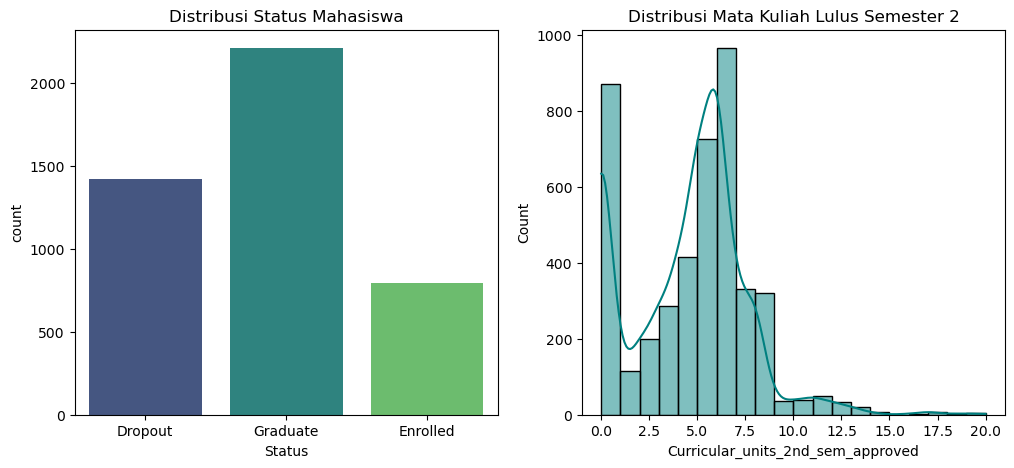

In [25]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.countplot(data=df_corr, x='Status', palette='viridis', hue='Status')
plt.title('Distribusi Status Mahasiswa')

plt.subplot(1, 2, 2)
sns.histplot(data=df_corr, x='Curricular_units_2nd_sem_approved', bins=20, kde=True, color='teal')
plt.title('Distribusi Mata Kuliah Lulus Semester 2')

plt.show()

Pada institusi Jaya Jaya Institut ini, terlihat bahwa tingkat graduate nya masih lebih tinggi dibanding total dropoutnya. Namun, banyak mahasiswa yang tidak lulus mata kuliah nya pada semester 2. Hal ini merupakan sinyal kuat bahwa kelompok mahasiswa ini kemungkinan besar akan melakukan dropout. Kebanyakan mahasiswa yang graduate itu mampu menyelesaikan 6 - 7 mata kuliah nya. Meskipun anggapan ini tidak 100% benar, tapi kalau kita melihat korelasi antara fitur target dengan fitur curricular_units_2nd_sem_approved cukup tinggi, yaitu di angka 0.62

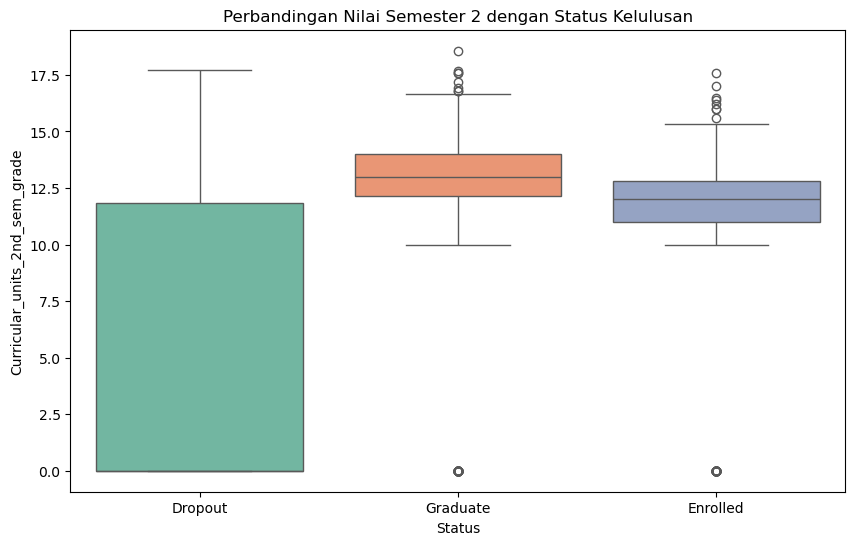

In [26]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_corr, x='Status', y='Curricular_units_2nd_sem_grade', palette='Set2', hue='Status')
plt.title('Perbandingan Nilai Semester 2 dengan Status Kelulusan')
plt.show()

Mahasiswa yang lulus memiliki median nilai semester 2 yang konsisten yaitu sekitar 12-14. Sebaliknya, untuk mahasiswa yang dropout memiliki sebaran yang luas, bahkan ada yang nilainya sampai 0. Ini mengindikasikan bahwa terdapat masalah akademik dari para mahasiswa kelompok ini.

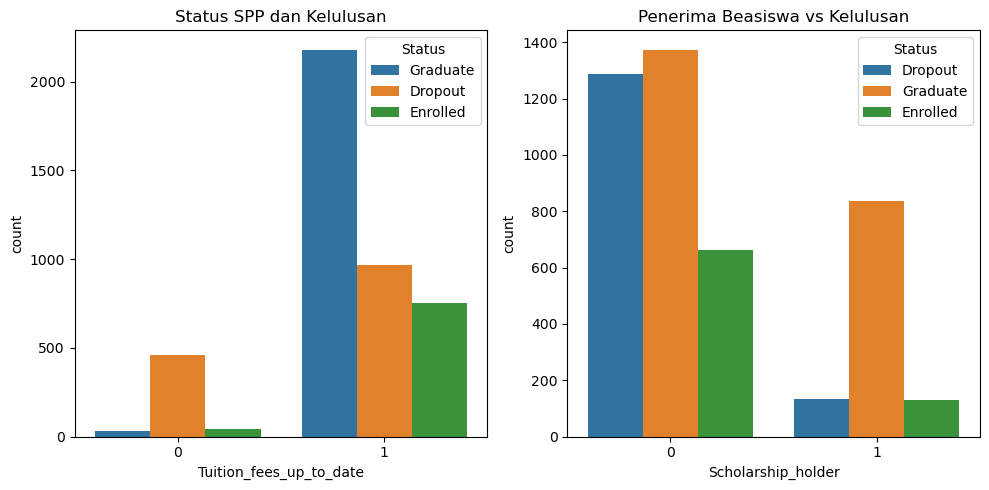

In [27]:
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
sns.countplot(data=df_corr, x='Tuition_fees_up_to_date', hue='Status')
plt.title('Status SPP dan Kelulusan')

plt.subplot(1, 2, 2)
sns.countplot(data=df_corr, x='Scholarship_holder', hue='Status')
plt.title('Penerima Beasiswa vs Kelulusan')

plt.tight_layout()
plt.show()

Mahasiswa yang sudah membayar SPP, tingkat graduatenya lebih dari 50% dibanding yang melakukan dropout. Selain itu, penerima beasiswa juga, memiliki tingkat kelulusan yang sangat tinggi. Ini mengindikasikan bahwa bantuan finansial bagi mahasiswa yang kurang mampu sangat membantu dan dapat menekan tingginya kasus dropout

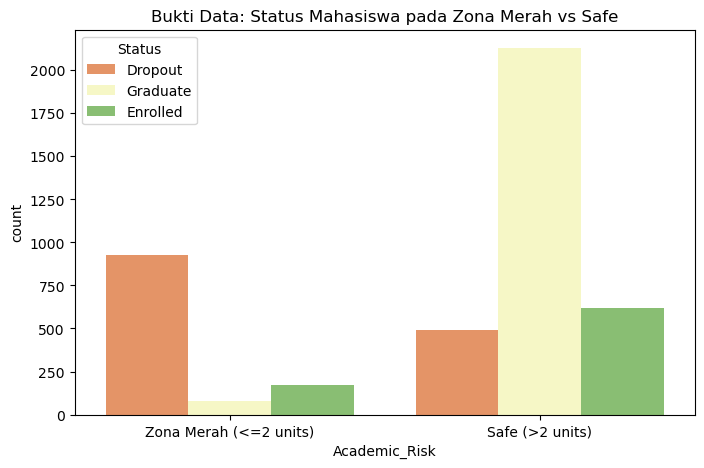

In [43]:
df_corr['Academic_Risk'] = df_corr['Curricular_units_2nd_sem_approved'].apply(lambda x: 'Zona Merah (<=2 units)' if x <=2 else 'Safe (>2 units)')

plt.figure(figsize=(8, 5))
sns.countplot(data=df_corr, x='Academic_Risk', hue='Status', palette='RdYlGn')
plt.title('Bukti Data: Status Mahasiswa pada Zona Merah vs Safe')
plt.show()

## Data Preparation / Preprocessing

In [28]:
# Menghapus status enrolled
df_prep = df[df['Status'] != 'Enrolled'].copy()

print(df_prep['Status'].value_counts())

Status
Graduate    2209
Dropout     1421
Name: count, dtype: int64


In [29]:
df_prep['Status'] = df_prep['Status'].map({
    'Graduate': 0,
    'Dropout': 1
})

In [30]:
df_prep.columns

Index(['Marital_status', 'Application_mode', 'Application_order', 'Course',
       'Daytime_evening_attendance', 'Previous_qualification',
       'Previous_qualification_grade', 'Nacionality', 'Mothers_qualification',
       'Fathers_qualification', 'Mothers_occupation', 'Fathers_occupation',
       'Admission_grade', 'Displaced', 'Educational_special_needs', 'Debtor',
       'Tuition_fees_up_to_date', 'Gender', 'Scholarship_holder',
       'Age_at_enrollment', 'International',
       'Curricular_units_1st_sem_credited',
       'Curricular_units_1st_sem_enrolled',
       'Curricular_units_1st_sem_evaluations',
       'Curricular_units_1st_sem_approved', 'Curricular_units_1st_sem_grade',
       'Curricular_units_1st_sem_without_evaluations',
       'Curricular_units_2nd_sem_credited',
       'Curricular_units_2nd_sem_enrolled',
       'Curricular_units_2nd_sem_evaluations',
       'Curricular_units_2nd_sem_approved', 'Curricular_units_2nd_sem_grade',
       'Curricular_units_2nd_sem_wit

In [31]:
choose_col = [
    'Application_mode',
    'Debtor',
    'Tuition_fees_up_to_date',
    'Gender',
    'Scholarship_holder',
    'Age_at_enrollment',
    'Curricular_units_1st_sem_approved',
    'Curricular_units_1st_sem_grade',
    'Curricular_units_2nd_sem_approved',
    'Curricular_units_2nd_sem_grade',
    'Status'
]

df_model = df_prep[choose_col].copy()
df_model.head()

,Application_mode,Debtor,Tuition_fees_up_to_date,Gender,Scholarship_holder,Age_at_enrollment,Curricular_units_1st_sem_approved,Curricular_units_1st_sem_grade,Curricular_units_2nd_sem_approved,Curricular_units_2nd_sem_grade,Status
0,17,0,1,1,0,20,0,0.000000,0,0.000000,1
1,15,0,0,1,0,19,6,14.000000,6,13.666667,0
2,1,0,0,1,0,19,0,0.000000,0,0.000000,1
3,17,0,1,0,0,20,6,13.428571,5,12.400000,0
4,39,0,1,0,0,45,5,12.333333,6,13.000000,0


In [32]:
X = df_model.drop(columns='Status')
y = df_model['Status']

In [33]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f'Total data latih: {X_train.shape[0]}')
print(f'Total data uji: {X_test.shape[0]}')

Total data latih: 2904
Total data uji: 726


## Modeling

In [34]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'criterion': ['gini', 'entropy']
}

rf_base = RandomForestClassifier(random_state=42)

grid_search = GridSearchCV(estimator=rf_base, param_grid=param_grid, cv=5, n_jobs=-1, scoring='accuracy')

grid_search.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'criterion': ['gini', 'entropy'], 'max_depth': [None, 10, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each

In [35]:
print('Parameter terbaik yang ditemukan:')
print(grid_search.best_params_)

best_rf_model = grid_search.best_estimator_

Parameter terbaik yang ditemukan:
{'criterion': 'gini', 'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 100}


In [36]:
rf_tuned = RandomForestClassifier(criterion= 'gini', max_depth= None, min_samples_leaf= 4, min_samples_split= 10, n_estimators= 200, random_state=42)

rf_tuned.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",10
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",4
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metri

## Evaluation

In [37]:
y_pred = rf_tuned.predict(X_test)

print(f'Akurasi: {accuracy_score(y_test, y_pred):.2%}')

Akurasi: 90.91%


In [38]:
print("--- Classification Report ---")
print(classification_report(y_test, y_pred))

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.92      0.94      0.93       442
           1       0.90      0.87      0.88       284

    accuracy                           0.91       726
   macro avg       0.91      0.90      0.90       726
weighted avg       0.91      0.91      0.91       726



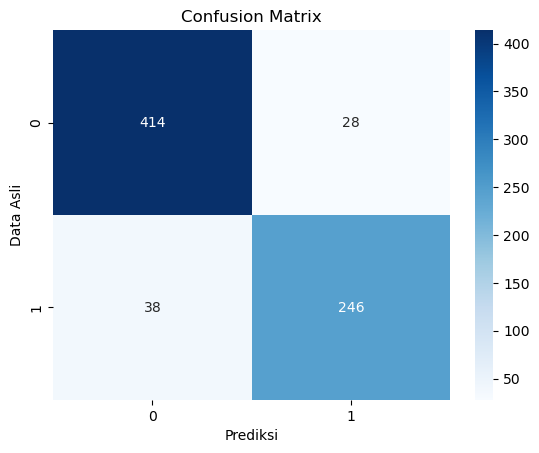

In [39]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(data=cm, annot=True, cmap='Blues', fmt='d')
plt.title('Confusion Matrix')
plt.xlabel('Prediksi')
plt.ylabel('Data Asli')
plt.show()

In [40]:
import joblib
import os

if not os.path.exists('model'):
    os.makedirs('model')
    
joblib.dump(rf_tuned, 'model/model_rf.joblib')

['model/model_rf.joblib']

In [41]:
df_model.to_csv('data_tableau.csv', index=False)

In [42]:
import importlib

libraries = {
    "pandas": "pandas",
    "numpy": "numpy",
    "scikit-learn": "sklearn",
    "imbalanced-learn": "imblearn",
    "streamlit": "streamlit",
    "matplotlib": "matplotlib",
    "seaborn": "seaborn",
    "joblib": "joblib"
}

for req_name, import_name in libraries.items():
    try:
        lib = importlib.import_module(import_name)
        print(f"{req_name}=={lib.__version__}")
    except ImportError:
        pass

pandas==2.3.1
numpy==2.1.3
scikit-learn==1.8.0
streamlit==1.45.1
matplotlib==3.10.0
seaborn==0.13.2
joblib==1.4.2
